In [1]:
import warnings
warnings.filterwarnings("ignore")

import os, pandas as pd, matplotlib.pyplot as plt, numpy as np, seaborn as sns, glob
from pynwb import NWBHDF5IO
from pathlib import Path
from convnwb.io import load_nwbfile
from scipy.ndimage import gaussian_filter1d

## load example data file

In [3]:
sess_file = sorted(glob.glob('../../data/000623/sub-CS53*/*.nwb'))[1]
# sess_file = sorted(glob.glob('../data/000623/sub-*/*.nwb'))[0]
nwbfile, io = load_nwbfile(os.path.basename(sess_file), os.path.dirname(sess_file), return_io=True)
nwbfile

Data type,int64
Shape,"(587,)"
Array size,4.59 KiB
Chunk shape,None
Compression,None
Compression opts,None
Compression ratio,1.0
Data type,float64
Shape,"(587,)"
Array size,4.59 KiB
Chunk shape,None


In [5]:
nwbfile.units.to_dataframe().to_csv('../input_data/csvs/units.csv')

## helper functions

In [8]:
# choose whether to normalize encoding FR by the trial's entire baseline or by the duration of baseline defined by shorted baseline
# norm_choice = 'shortest_baseline'
# norm_choice = 'session_baseline'
norm_choice = 'self'
# norm_choice = 'nothing'

# Function to handle spike filtering, aligning, truncating, and FR calculation
def process_spikes(neuron, trial_df):

    trials_spikes_filtered, trials_spikes_aligned = [], []
    trials_num_spikes, trials_FR = [], []
    trials_smooth_spikes, trials_smooth_FR = [], []
    
    sess_max_RT = np.max(trial_df['RT'][1:]) # used to set xlim for recognition task rasters
    shortest_baseline_RT = 11.6 # used to set xlim for baseline, which is used for normalization

    for _, trial in trial_df.iterrows():
        
        # 1. Filter spike times within trial's start and stop times
        trial_spikes = neuron['spike_times'][
            (neuron['spike_times'] >= trial['start_time']) &
            (neuron['spike_times'] <= trial['stop_time'])
        ]
        
        # 2. align spike times to trial onset
        trial_spikes_aligned = trial_spikes - trial['start_time']

        # 3. num_spikes
        trial_num_spikes = len(trial_spikes_aligned)

        # 4. firing rate
        trial_FR = len(trial_spikes_aligned)/trial['RT']

        # 5. smooth spikes

        win_size, step = 3, 1
        
        if trial['stim_phase'] == 'encoding':
            stop = trial['RT']

        elif trial['stim_phase'] == 'baseline':
            
            print('baseline')
            if norm_choice == 'shortest_baseline':
                stop = shortest_baseline_RT
            elif norm_choice == 'session_baseline':
                stop = trial['RT']
            elif norm_choice == 'self':
                stop = trial['RT']
            elif norm_choice == 'nothing':
                stop = 0


        elif trial['stim_phase'] == 'recognition':
            stop, win_size, step = sess_max_RT, 1, .5
        
        trial_smooth_spikes = []

        # # a. boxcar filter
        for i in np.arange(0, stop-win_size+step, step):
            trial_smooth_spikes.append(len(trial_spikes_aligned[(trial_spikes_aligned >= i) & (trial_spikes_aligned < i + win_size)]))

        # # b. gaussian filter
        # dt, true_sigma = .01, .1
        # t = np.arange(0, stop, dt) # time vector with num_elements = bins
        # spike_train = np.zeros_like(t) # initialize bins to 0s
        # inds = ((np.array(trial_spikes_aligned)) / dt).astype(int) # map spike times to bins
        # inds = inds[inds < len(t)]
        # spike_train[inds] = 1
        # trial_smooth_spikes = gaussian_filter1d(spike_train, sigma=true_sigma/dt) / dt  # convert from rate-per-bin to rate-per-second (FR)

        # 6. FR of smooth spikes
        trial_smooth_FR = np.mean(trial_smooth_spikes)
        
        # NORMALIZING
        if trial['stim_phase'] == 'encoding' and norm_choice == 'self':

            base_mean = np.nanmean(trial_smooth_spikes)
            base_sd = np.nanstd(trial_smooth_spikes)
        
            if base_sd > 0:
                trial_smooth_spikes = (trial_smooth_spikes - base_mean) / base_sd
                trial_smooth_FR = np.mean(trial_smooth_spikes)
                                          
        # if we just filtered baseline spikes, use it to normalize encoding
        if trial['stim_phase'] == 'baseline' and not norm_choice == 'self':

            base_mean = np.nanmean(trial_smooth_spikes)
            base_sd = np.nanstd(trial_smooth_spikes)
        
            if base_sd > 0:
                # -1 indexing to access encoding trial which was processed just prior to baseline
                trials_smooth_spikes[-1] = (trials_smooth_spikes[-1] - base_mean) / base_sd
                trials_smooth_FR[-1] = np.mean(trials_smooth_spikes[-1])


        # Append results to lists
        trials_spikes_filtered.append(trial_spikes)
        trials_spikes_aligned.append(trial_spikes_aligned)
        trials_num_spikes.append(trial_num_spikes)
        trials_FR.append(trial_FR)
        trials_smooth_spikes.append(trial_smooth_spikes)
        trials_smooth_FR.append(trial_smooth_FR)

    return trials_spikes_filtered, trials_spikes_aligned, trials_num_spikes, trials_FR, trials_smooth_spikes, trials_smooth_FR


## consolidate dataframe

In [9]:
print(f' normalize by {norm_choice}')

session_files = sorted(glob.glob('../../data/000623/sub-*/*.nwb'))
neuron_by_trial = []
row_counter = 0

# create table comprising n_rows = n_neurons * n_trials = ~1457 * 41
for session_file in session_files:
    
    nwbfile, io = load_nwbfile(os.path.basename(session_file), os.path.dirname(session_file), return_io=True)
    subj = os.path.basename(session_file)[:8]

    # trial data per session
    trial_df = nwbfile.trials.to_dataframe()
    
    # create a 'baseline' row
    baseline_row = {
        'start_time': trial_df['stop_time'].iloc[0],
        'stop_time': trial_df['start_time'].iloc[1],
        'stim_phase': 'baseline',
        'stimulus_file': 'NA',
        'response_correct': 'NA',
        'response_confidence': 'NA',
        'actual_response': 'NA'
    }

    # baseline row at index 1
    trial_df = pd.concat([trial_df.iloc[:1], pd.DataFrame([baseline_row]), trial_df.iloc[1:]]).reset_index(drop=True)

    trial_df['RT'] = trial_df['stop_time'] - trial_df['start_time']
    
    # all neurons within session
    neur_df = nwbfile.units.to_dataframe()[['unit_id_session', 'electrode_id', 'spike_times']]
    
    neur_df['subj'] = neur_df['unit_id_session'].str[:3]
    neur_df['sess'] = neur_df['unit_id_session'].str[:8]
    neur_df = neur_df.rename(columns={'unit_id_session': 'neuron'})

    # electrode info
    electrodes_df = nwbfile.electrodes.to_dataframe()
    
    # Replace unit_id in neur_df with the corresponding location from electrodes_df
    neur_df['electrode_id'] = neur_df['electrode_id'].map(electrodes_df['location'])
    neur_df['electrode_id'] = neur_df['electrode_id'].str.split().str[-1]
    neur_df = neur_df.rename(columns={'electrode_id': 'region'})

    for neuron in range(len(neur_df)):
    
        # get specific neuron's spike info
        neuron_row = neur_df.iloc[neuron]

        # Repeat the neuron row as many times as there are trials
        repeated_neuron_row = pd.DataFrame([neuron_row] * len(trial_df)).reset_index(drop=True)

        # Concatenate the neuron data with the trial data horizontally
        neur_tri_df = pd.concat([repeated_neuron_row, trial_df.reset_index(drop=True)], axis=1)
        
        (
            neur_tri_df['trial_spikes'],  # within trial spikes
            neur_tri_df['trial_aligned_spikes'],  # spikes aligned to start
            neur_tri_df['trial_smooth_spikes'],  # spikes smoothed using sliding window
            neur_tri_df['num_spikes'],  # number of spikes
            neur_tri_df['FR'],  # len(spikes)/RT
            neur_tri_df['trial_smooth_FR']  # FR of smoothed spikes
        ) = process_spikes(neuron_row, trial_df)

        # Finally, append the neur_tri_df for this neuron to the overall df
        neuron_by_trial.append(neur_tri_df)

    print(subj)
   
neuron_by_trial = pd.concat(neuron_by_trial, ignore_index=True)

# reorder cols
neuron_by_trial = neuron_by_trial[['subj', 'sess', 'neuron', 'region',
                                   'start_time', 'stop_time', 'RT',
                                   'trial_spikes', 'trial_aligned_spikes', 'num_spikes', 'FR',
                                   'trial_smooth_spikes', 'trial_smooth_FR',
                                   'stim_phase', 'stimulus_file',
                                   'response_correct', 'response_confidence', 'actual_response']]

# neuron_by_trial.to_pickle(f'./data_files/neuron_by_trial_norm_by_{norm_choice}.pkl')
# neuron_by_trial.to_pickle(f'./data_files/neuron_by_trial_norm_by_{norm_choice}_pkl3.pkl', protocol=3)
# import joblib
# joblib.dump(neuron_by_trial, './data_files/neuron_by_trial_norm_by_{norm_choice}_alt.joblib')
# neuron_by_trial.reset_index(drop=True).to_csv(f'./data_files/neuron_by_trial_norm_by_{norm_choice}.csv', index=False)

    

 normalize by self
baseline
baseline
baseline
baseline
baseline
baseline
baseline
sub-CS41
baseline
baseline
baseline
baseline
baseline
baseline
baseline
sub-CS41
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
sub-CS42
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline
baseline


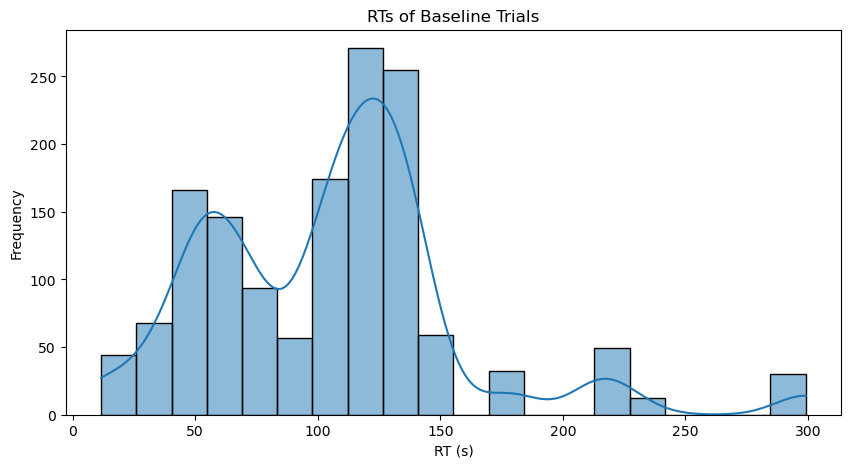

In [12]:
df_baseline = neuron_by_trial[neuron_by_trial['stim_phase'] == 'baseline'].reset_index(drop=True)
# plot hist of RTs
plt.figure(figsize=(10, 5))
sns.histplot(df_baseline['RT'], bins=20, kde=True)
plt.title('RTs of Baseline Trials')
plt.xlabel('RT (s)')
plt.ylabel('Frequency')
plt.show()

## check

In [12]:
df_baseline = neuron_by_trial[neuron_by_trial['stim_phase'] == 'baseline']

unique_RTs = np.unique(df_baseline['RT'])
unique_lengths = np.unique([len(smooth_spikes) for smooth_spikes in df_baseline['trial_smooth_spikes']])

print(f'normalizing by {norm_choice}\n')
print(f'{len(unique_RTs)} unique RTs: {unique_RTs})\n')
print(f'{len(unique_lengths)} unique smooth spikes vector lengths: {unique_lengths})')

neuron_by_trial.head()

TypeError: object of type 'int' has no len()

In [ ]:
print(df_baseline['trial_smooth_spikes'].head())

1       50
43      61
85     197
127    252
169     59
Name: trial_smooth_spikes, dtype: int64
